In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.metrics import precision_recall_curve

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

class PortScanDetector(nn.Module):
    def __init__(self, input_dim=29, num_classes=2):
        super(PortScanDetector, self).__init__()
        self.layer1 = nn.Linear(input_dim, 64)
        self.layer2 = nn.Linear(64, 32)
        self.output = nn.Linear(32, num_classes)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.dropout(x)
        x = self.relu(self.layer2(x))
        return self.output(x)

In [3]:
def load_and_preprocess(filepath):
    df = pd.read_csv(filepath)
    
    # 1. Drop parity columns
    cols_to_drop = [
        "Fwd Packets Length Total", "Bwd Packets Length Total", "Fwd Packet Length Max", 
        "Bwd Packet Length Max", "Fwd Packet Length Min", "Bwd Packet Length Min",
        "Fwd Packet Length Std", "Bwd Packet Length Std", "Flow IAT Std", "Flow IAT Total",
        "Fwd IAT Std", "Fwd IAT Max", "Fwd IAT Min", "Bwd IAT Total", "Bwd IAT Std", 
        "Bwd IAT Max", "Bwd IAT Min", "Fwd PSH Flags", "Bwd PSH Flags", "Fwd URG Flags", 
        "Bwd URG Flags", "Packet Length Variance", "PSH Flag Count", "URG Flag Count", 
        "CWE Flag Count", "ECE Flag Count", "Down/Up Ratio", "Avg Packet Size",
        "Avg Fwd Segment Size", "Avg Bwd Segment Size", "Fwd Avg Bytes/Bulk", 
        "Fwd Avg Packets/Bulk", "Fwd Avg Bulk Rate", "Bwd Avg Bytes/Bulk", 
        "Bwd Avg Packets/Bulk", "Bwd Avg Bulk Rate", "Subflow Bwd Bytes",
        "Init Fwd Win Bytes", "Init Bwd Win Bytes", "Fwd Act Data Packets", 
        "Fwd Seg Size Min", "Active Mean", "Active Std", "Active Max", "Active Min",
        "Idle Mean", "Idle Std", "Idle Max", "Idle Min"
    ]
    df = df.drop(columns=cols_to_drop, axis=1, errors='ignore')
    
    # 2. Pre-Transformation Cleaning
    # Replace existing inf/NaN and clip large values before log
    df = df.replace([np.inf, -np.inf], np.nan).fillna(0)
    
    X = df.drop('Label', axis=1)
    X = X.clip(lower=0, upper=1e12) # Log1p requires values >= -1; clipping at 0 is safer
    y = df['Label'].map({'Benign': 0, 'PortScan': 1}).values
    
    # 3. Log Transformation
    # Apply log1p and immediately check for new inf/NaN values produced by the calc
    X_log = np.log1p(X.values)
    X_log = np.nan_to_num(X_log, nan=0.0, posinf=0.0, neginf=0.0)
    
    # 4. Scaling
    scaler = StandardScaler()
    X_final = scaler.fit_transform(X_log)
    
    return train_test_split(X_final, y, test_size=0.2, stratify=y, random_state=42)

In [4]:
def train_local(model, train_loader, epochs=5):
    # CrossEntropyLoss is used for multi-class/binary classification
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    model.train()
    for epoch in range(epochs):
        for inputs, labels in train_loader:
            inputs = torch.tensor(inputs, dtype=torch.float)
            labels = torch.tensor(labels, dtype=torch.long)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
    
    return model.state_dict()

In [5]:
def evaluate_model(model, X_test, y_test):
    model.eval()
    X_test_tensor = torch.tensor(X_test, dtype=torch.float)
    
    with torch.no_grad():
        outputs = model(X_test_tensor)
        probs = torch.softmax(outputs, dim=1)[:, 1].numpy() 
        preds = torch.argmax(outputs, dim=1).numpy()
    
    print("\n--- CLASSIFICATION REPORT ---")
    print(classification_report(y_test, preds, target_names=['Benign', 'PortScan']))
    
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(12, 5))
    
    # Plot ROC Curve
    plt.subplot(1, 2, 1)
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc="lower right")
    
    # Plot Confusion Matrix
    plt.subplot(1, 2, 2)
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'PortScan'], yticklabels=['Benign', 'PortScan'])
    plt.title('Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    
    plt.tight_layout()
    plt.show()

Original class distribution: [94052  1565]
Balanced distribution: [94045  9398]
Training XGBoost with SMOTE-balanced data...


C:\Users\Mohammad Saquib\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Optimal Threshold Found: 0.9303

--- CLASSIFICATION REPORT (XGBoost + SMOTE) ---
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00     23514
    PortScan       0.90      0.93      0.91       391

    accuracy                           1.00     23905
   macro avg       0.95      0.96      0.96     23905
weighted avg       1.00      1.00      1.00     23905



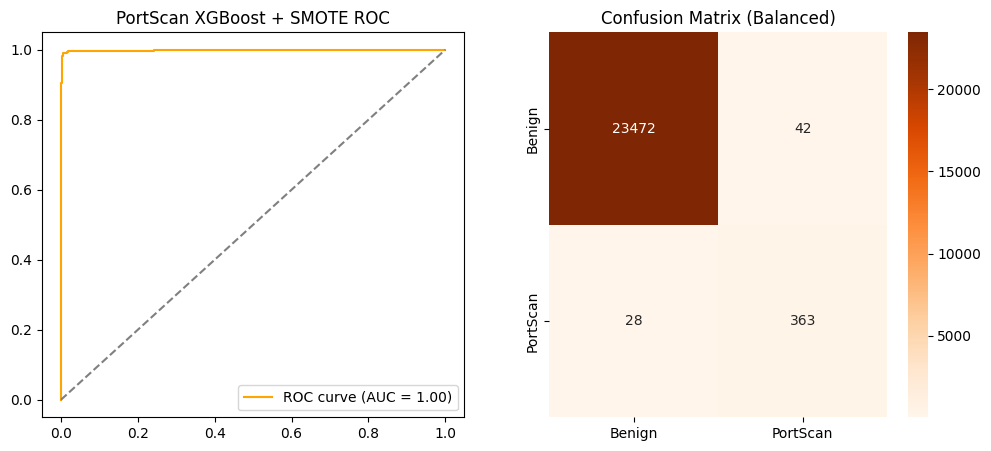

In [6]:
if __name__ == "__main__":
    # Load PortScan Dataset
    data_path = "C:\\Datasets\\IDS_Dataset\\Portscan-Friday-no-metadata.csv"
    X_train, X_test, y_train, y_test = load_and_preprocess(data_path)
    
    # --- STEP 3: Apply SMOTE to fix class imbalance ---
    print(f"Original class distribution: {np.bincount(y_train)}")
    smt = SMOTETomek(sampling_strategy=0.1, random_state=42)
    X_train_res, y_train_res = smt.fit_resample(X_train, y_train)
    print(f"Balanced distribution: {np.bincount(y_train_res)}")
    
    # --- STEP 4: Initialize and Train XGBoost ---
    model = LogisticRegression(max_iter=2000, C=1, warm_start=True, solver="saga", class_weight="balanced")
    
    print("Training XGBoost with SMOTE-balanced data...")
    model.fit(X_train_res, y_train_res)
    
    # --- STEP 5: Evaluation ---
    y_pred = model.predict(X_test)
    y_probs = model.predict_proba(X_test)[:, 1]
    precision, recall, thresholds = precision_recall_curve(y_test, y_probs)
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
    optimal_idx = np.argmax(f1_scores)
    best_threshold = thresholds[optimal_idx]
    
    print(f"Optimal Threshold Found: {best_threshold:.4f}")
    
    y_pred_final = (y_probs >= best_threshold).astype(int)
    
    print("\n--- CLASSIFICATION REPORT (XGBoost + SMOTE) ---")
    print(classification_report(y_test, y_pred_final, target_names=['Benign', 'PortScan']))
    
    # ROC-AUC
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)
    
    # Plotting
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})', color='orange')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.title('PortScan XGBoost + SMOTE ROC')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    cm = confusion_matrix(y_test, y_pred_final)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=['Benign', 'PortScan'], yticklabels=['Benign', 'PortScan'])
    plt.title('Confusion Matrix (Balanced)')
    plt.show()

In [7]:
import joblib

# Save the model to a pkl file
joblib.dump(model, 'model_2.pkl') # Change name for each file
print("Model saved as pkl for Federated Aggregation.")

Model saved as pkl for Federated Aggregation.
